<a href="https://colab.research.google.com/github/balasri03/Mini_project/blob/main/Vast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
data_test = pd.read_csv("/content/VAST_test.csv")
data_train = pd.read_csv("/content/VAST_train_11k.csv")
data_val = pd.read_csv("/content/VAST_val.csv")
print(data_test.head())
print("Dataset shape:", data_test.shape)
print(data_train.head())
print("Dataset shape:", data_train.shape)
print(data_val.head())
print("Dataset shape:", data_val.shape)

                                               Tweet             Target 1  \
0  I totally agree with this premise. As a younge...        nuclear power   
1  I totally agree with this premise. As a younge...        nuclear power   
2  Who is the mayor of N.Y. to assume he has the ...    illegal immigrant   
3  Who is the mayor of N.Y. to assume he has the ...  illegal immigration   
4  Who is the mayor of N.Y. to assume he has the ...            immigrant   

  Stance 1  seen?  
0    FAVOR      0  
1    FAVOR      0  
2  AGAINST      1  
3  AGAINST      1  
4  AGAINST      1  
Dataset shape: (3006, 4)
                                               Tweet                Target 1  \
0  Regulation of corporations has been subverted ...                 company   
1  Regulation of corporations has been subverted ...              regulation   
2  Regulation of corporations has been subverted ...    corporate regulation   
3  Regulation of corporations has been subverted ...  regulation corpora

In [ ]:
from scipy.sparse import data
data_train.columns = data_train.columns.str.strip()

print("Columns:", data_train.columns)
data_val.columns = data_val.columns.str.strip()

print("Columns:", data_val.columns)
data_test.columns = data_test.columns.str.strip()

print("Columns:", data_test.columns)

Columns: Index(['Tweet', 'Target 1', 'Stance 1', 'seen?'], dtype='object')
Columns: Index(['Tweet', 'Target 1', 'Stance 1', 'seen?'], dtype='object')
Columns: Index(['Tweet', 'Target 1', 'Stance 1', 'seen?'], dtype='object')


In [ ]:
data_train['input_text'] = data_train['Tweet'] + " target " + data_train['Target 1']
print(data_train[['input_text']].head())

data_val['input_text'] = data_val['Tweet'] + " target " + data_val['Target 1']
print(data_val[['input_text']].head())

data_test['input_text'] = data_test['Tweet'] + " target " + data_test['Target 1']
print(data_test[['input_text']].head())

                                          input_text
0  Regulation of corporations has been subverted ...
1  Regulation of corporations has been subverted ...
2  Regulation of corporations has been subverted ...
3  Regulation of corporations has been subverted ...
4  Absolutely it's needs to be defined and regula...
                                          input_text
0  The comments can "improve the quality of work ...
1  Is there zero personal accountability in today...
2  Is there zero personal accountability in today...
3  Is there zero personal accountability in today...
4  Look, there are issues to be debateed. Do we n...
                                          input_text
0  I totally agree with this premise. As a younge...
1  I totally agree with this premise. As a younge...
2  Who is the mayor of N.Y. to assume he has the ...
3  Who is the mayor of N.Y. to assume he has the ...
4  Who is the mayor of N.Y. to assume he has the ...


In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text

In [ ]:
data_train['input_text'] = data_train['input_text'].apply(clean_text)
data_val['input_text'] = data_val['input_text'].apply(clean_text)
data_test['input_text'] = data_test['input_text'].apply(clean_text)

In [ ]:
print(data_train.columns)
print(data_val.columns)
print(data_test.columns)

Index(['Tweet', 'Target 1', 'Stance 1', 'seen?', 'input_text'], dtype='object')
Index(['Tweet', 'Target 1', 'Stance 1', 'seen?', 'input_text'], dtype='object')
Index(['Tweet', 'Target 1', 'Stance 1', 'seen?', 'input_text'], dtype='object')


In [ ]:
encoder = LabelEncoder()

data_train['label'] = encoder.fit_transform(data_train['Stance 1'])
data_val['label'] = encoder.transform(data_val['Stance 1'])
data_test['label'] = encoder.transform(data_test['Stance 1'])

In [ ]:
data_train['label'].value_counts()

,count
label,
0,4507
1,4302
2,2496


In [ ]:
tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(data_train['input_text'])

sequences_train = tokenizer.texts_to_sequences(data_train['input_text'])
sequences_val   = tokenizer.texts_to_sequences(data_val['input_text'])
sequences_test  = tokenizer.texts_to_sequences(data_test['input_text'])

In [ ]:
encoder = LabelEncoder()

data_train['label'] = encoder.fit_transform(data_train['Stance 1'])
data_val['label'] = encoder.transform(data_val['Stance 1'])
data_test['label'] = encoder.transform(data_test['Stance 1'])

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Step 1: Define your text data
texts = ["I love coding", "Deep learning is fun"]

# Step 2: Create tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)

# Step 3: Convert text → sequences
sequences = tokenizer.texts_to_sequences(texts)

# Step 4: Padding
max_len = 100
X = pad_sequences(sequences, maxlen=max_len)

print(X)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 2 3]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 5 6 7]]


In [ ]:
X_train = pad_sequences(tokenizer.texts_to_sequences(data_train['input_text']), maxlen=max_len)
X_test  = pad_sequences(tokenizer.texts_to_sequences(data_test['input_text']), maxlen=max_len)
y_train = data_train['label']
y_test  = data_test['label']

In [ ]:
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)
print("Max sequence length:", max_len)

Vocabulary size: 8
Max sequence length: 100


load glove

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-04-02 06:17:38--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-04-02 06:17:38--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-04-02 06:17:38--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [ ]:
import numpy as np

embedding_dim = 100
embeddings_index = {}

with open("glove.6B.100d.txt", encoding="utf8") as f:

    for line in f:

        values = line.split()

        word = values[0]

        vector = np.asarray(values[1:], dtype='float32')

        embeddings_index[word] = vector

print("Total words in GloVe:", len(embeddings_index))

Total words in GloVe: 400000


In [ ]:
vocab_size = len(tokenizer.word_index) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():

    vector = embeddings_index.get(word)

    if vector is not None:

        embedding_matrix[i] = vector

In [ ]:
X = pad_sequences(
    tokenizer.texts_to_sequences(data_train['input_text']),
    maxlen=max_len
)

y = data_train['label']   # ✅ same dataset

In [ ]:
class_weights = {
    0: 1.0,
    1: 1.0,
    2: 1.3   # small boost only
}

In [ ]:
input_layer = Input(shape=(max_len,))

embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=True
)(input_layer)

lstm_layer = LSTM(128)(embedding_layer)

dense = Dense(64, activation='relu')(lstm_layer)
drop = Dropout(0.5)(dense)

output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 100, 100)       │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,499 (494.14 KB)

 Trainable params: 126,499 (494.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
start_train = time.time()

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

end_train = time.time()

train_time = end_train - start_train

print("Training Time:", train_time)

Epoch 1/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4167 - loss: 1.0725
Epoch 2/20
 22/354 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3752 - loss: 1.0772

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4223 - loss: 1.0682
Epoch 3/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4312 - loss: 1.0657
Epoch 4/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4316 - loss: 1.0644
Epoch 5/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4318 - loss: 1.0649
Epoch 6/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4321 - loss: 1.0633
Epoch 7/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4345 - loss: 1.0633
Epoch 8/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4351 - loss: 1.0639
Epoch 9/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4360 - loss: 1.0618
Epoch 10/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4308 - loss: 1.0619
Epoch 11/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4373 - loss: 1.0613
Epoch 12/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4396 - loss: 1.0616
Epoch 13/20
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accu

In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 126499
Parameters (Millions): 0.126499


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
params = model.count_params()

params_m = params / 1e6

In [ ]:
results = [] # Re-initialize the results list
results.append({
    "Model": "LSTM (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

          Model  Accuracy  Precision   Recall  F1 score  Train Time(sec)  \
0  LSTM (GloVe)  0.354624   0.237964  0.35652  0.271439        67.944947   

   Inference Time(sec)  Parameters(M)  
0             0.580102       0.126499  


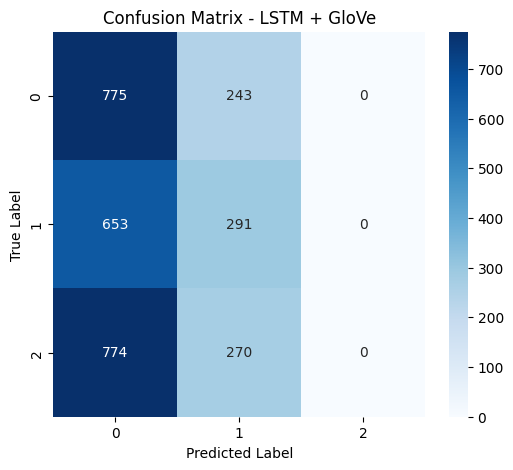

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - LSTM + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

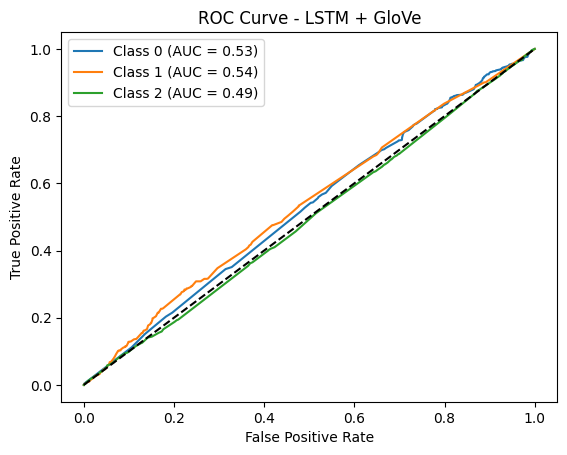

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM + GloVe")

plt.legend()
plt.show()

Attention


In [ ]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
input_layer = Input(shape=(max_len,))

# Embedding layer (GloVe)
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=True
)(input_layer)

# 🔥 LSTM with sequences (important for attention)
lstm_layer = LSTM(128, return_sequences=True)(embedding_layer)

# 🔥 Attention
attention = Attention()([lstm_layer, lstm_layer])

# 🔥 Pooling (convert sequence → vector)
pooling = GlobalMaxPooling1D()(attention)

# Dense layers
dense1 = Dense(128, activation='relu')(pooling)
dense2 = Dense(64, activation='relu')(dense1)

drop = Dropout(0.5)(dense2)

# Output
output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 100, 100)  │        800 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 100, 128)  │    117,248 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 100, 128)  │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ attention_1[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     16,512 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 143,011 (558.64 KB)

 Trainable params: 143,011 (558.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class_weights = {
    0: 1.1,
    1: 1.0,
    2: 1.8
}

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights
)

Epoch 1/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4678 - loss: 1.2253 - val_accuracy: 0.0000e+00 - val_loss: 1.3538
Epoch 2/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4788 - loss: 1.2179 - val_accuracy: 0.0000e+00 - val_loss: 1.8650
Epoch 3/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4744 - loss: 1.2204 - val_accuracy: 0.0000e+00 - val_loss: 1.4952
Epoch 4/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4774 - loss: 1.2187 - val_accuracy: 0.0000e+00 - val_loss: 1.5112
Epoch 5/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4766 - loss: 1.2178 - val_accuracy: 0.0000e+00 - val_loss: 1.4568
Epoch 6/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4811 - loss: 1.2152 - val_accuracy: 0.0000e+00 - val_loss: 1.6212
Epoch 7/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4780 - loss: 1.2165 - val_accuracy: 0.0000e+00 - val_loss: 1.5201
Epoch 8/25
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.485

In [ ]:
start_inf = time.time()
pred = model.predict(X_test)
end_inf = time.time()
inference_time = end_inf - start_inf

pred_classes = np.argmax(pred, axis=1)
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Total Parameters: 143011
Parameters (Millions): 0.143011


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

params_m = params / 1e6

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results = []

results.append({
    "Model": "LSTM (attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

print(results_df)

              Model  Accuracy  Precision  Recall  F1 score  Train Time(sec)  \
0  LSTM (attention)  0.347638   0.231892   0.347  0.248444        67.944947   

   Inference Time(sec)  Parameters(M)  
0             0.594275       0.143011  


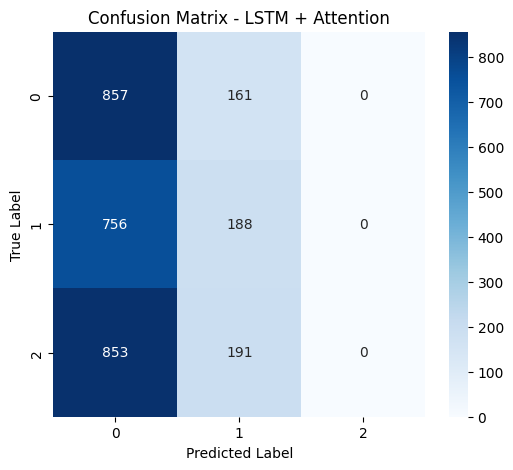

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - LSTM + Attention")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

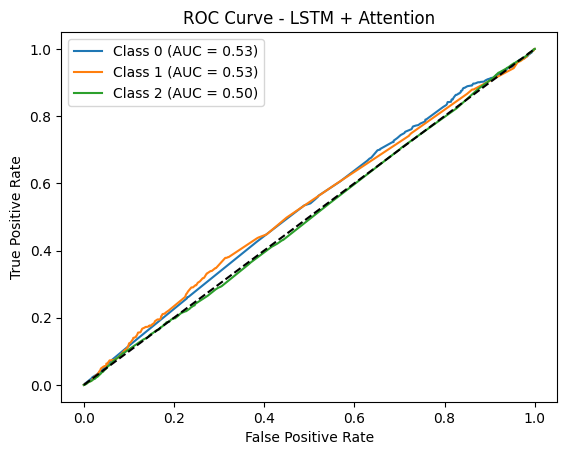

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM + Attention")

plt.legend()
plt.show()

minlstm+glove

In [ ]:
import time
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# MINI LSTM (smaller units)
lstm_layer = LSTM(32)(embedding_layer)

# Dropout
dropout_layer = Dropout(0.5)(lstm_layer)

# Output layer
output_layer = Dense(3, activation='softmax')(dropout_layer)

# Model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 100, 100)       │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,923 (70.01 KB)

 Trainable params: 17,123 (66.89 KB)

 Non-trainable params: 800 (3.12 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4209 - loss: 1.0740
Epoch 2/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4343 - loss: 1.0638
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4370 - loss: 1.0636
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4346 - loss: 1.0636
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4336 - loss: 1.0632
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4393 - loss: 1.0624
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4357 - loss: 1.0622
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4378 - loss: 1.0619
Epoch 9/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4353 - loss: 1.0610
Epoch 10/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4356 - loss: 1.0608


In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()
inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 17923
Parameters (Millions): 0.017923


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results = []

results.append({
    "Model": "MiniLSTM (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [ ]:
# This cell previously contained code to delete entries, which led to an empty results list.
# It has been removed to prevent accidental clearing of results. Please re-run the model
# evaluation cells to populate the 'results' list with all desired model metrics.

# Recreate and print the DataFrame with only
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

              Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  MiniLSTM (GloVe)   0.35163   0.236116  0.353188  0.267387        29.552627   

   Inference Time(sec)  Parameters(M)  
0             0.563068       0.143011  


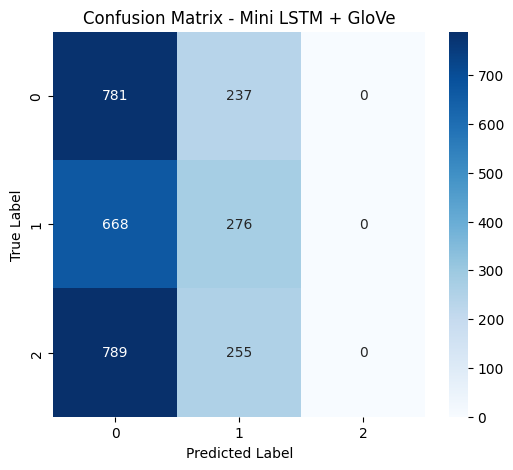

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Mini LSTM + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

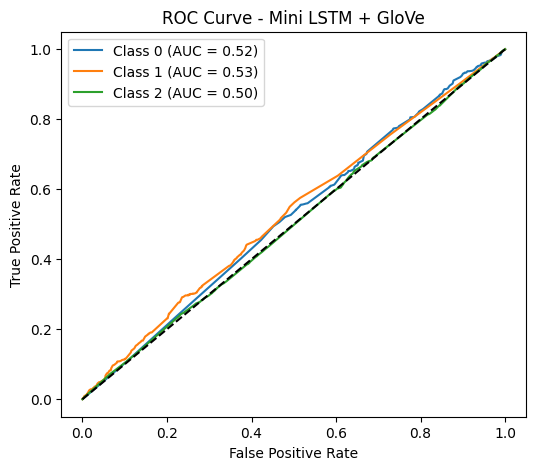

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini LSTM + GloVe")

plt.legend()
plt.show()

minlstm+attention

In [ ]:
from tensorflow.keras.layers import BatchNormalization
input_layer = Input(shape=(max_len,))

# Embedding
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=True
)(input_layer)

# 🔥 Mini LSTM (improved)
lstm_out = LSTM(96, return_sequences=True)(embedding_layer)

# 🔥 Attention
attention_out = Attention()([lstm_out, lstm_out])

# 🔥 Pooling
context = GlobalMaxPooling1D()(attention_out)

# Dense layers
dense1 = Dense(64, activation='relu')(context)
bn = BatchNormalization()(dense1)

drop = Dropout(0.5)(bn)

# Output
output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),   # stable LR
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]

)
end_train = time.time()
train_time = end_train - start_train

Epoch 1/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.4064 - loss: 1.0808
Epoch 2/15
 19/354 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4273 - loss: 1.0581

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4278 - loss: 1.0644
Epoch 3/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4285 - loss: 1.0648
Epoch 4/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4260 - loss: 1.0657
Epoch 5/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4287 - loss: 1.0648
Epoch 6/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4323 - loss: 1.0636
Epoch 7/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4323 - loss: 1.0631
Epoch 8/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4310 - loss: 1.0638
Epoch 9/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4303 - loss: 1.0638
Epoch 10/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4302 - loss: 1.0634
Epoch 11/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4340 - loss: 1.0639
Epoch 12/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4310 - loss: 1.0635
Epoch 13/15
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - a

In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 83107
Parameters (Millions): 0.083107


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results = []

results.append({
    "Model": "MiniLSTM (attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params_m
})

In [ ]:
# Recreate and print the DataFrame with only
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

                  Model  Accuracy  Precision    Recall  F1 score  \
0  MiniLSTM (attention)  0.336993   0.226829  0.347174  0.269602   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
0        85.950477             0.605184       0.143011  


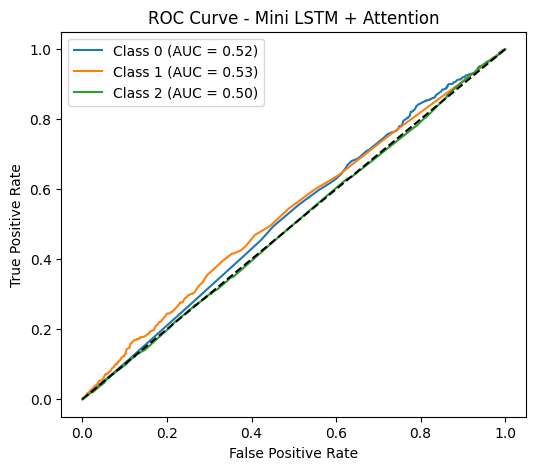

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini LSTM + Attention")

plt.legend()
plt.show()

gru+glove

In [ ]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe Embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# GRU layer
gru_layer = GRU(128, dropout=0.3, recurrent_dropout=0.3)(embedding_layer)

# Dropout
drop = Dropout(0.3)(gru_layer)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 100, 100)       │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,507 (349.64 KB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 800 (3.12 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 99s 269ms/step - accuracy: 0.4051 - loss: 1.0939
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


354/354 ━━━━━━━━━━━━━━━━━━━━ 97s 273ms/step - accuracy: 0.4235 - loss: 1.0738
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 142s 274ms/step - accuracy: 0.4263 - loss: 1.0684
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 97s 273ms/step - accuracy: 0.4344 - loss: 1.0658
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 143s 275ms/step - accuracy: 0.4326 - loss: 1.0649
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 142s 274ms/step - accuracy: 0.4317 - loss: 1.0634
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 141s 272ms/step - accuracy: 0.4343 - loss: 1.0645
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 97s 273ms/step - accuracy: 0.4376 - loss: 1.0625
Epoch 9/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 142s 272ms/step - accuracy: 0.4340 - loss: 1.0630
Epoch 10/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 96s 272ms/step - accuracy: 0.4361 - loss: 1.0627


In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()
inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 89507
Parameters (Millions): 0.089507


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results = []
results.append({
    "Model": "GRU (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [ ]:
# Recreate and print the DataFrame with only
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

         Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
0  GRU (GloVe)  0.349967   0.233308  0.353296  0.274223      1195.099065   

   Inference Time(sec)  Parameters(M)  
0             7.545007       0.089507  


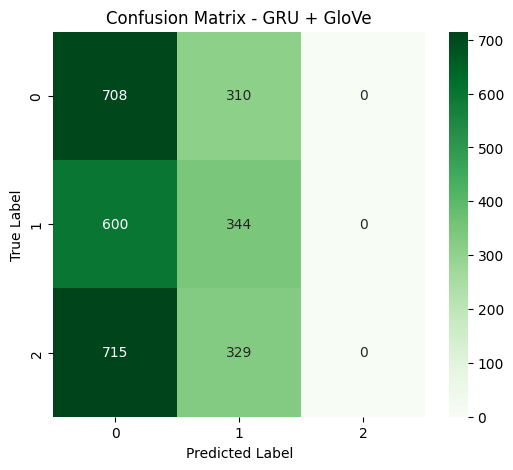

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - GRU + GloVe")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

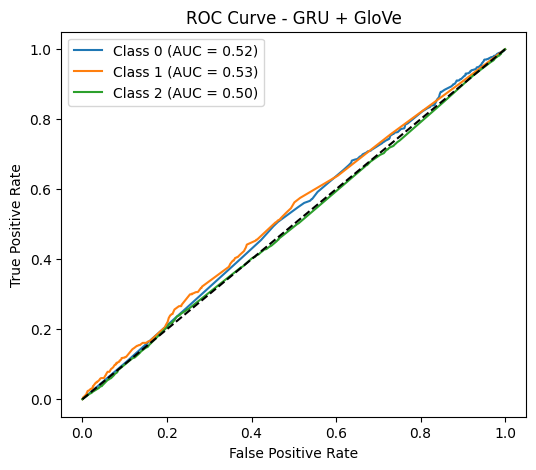

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary format
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU + GloVe")

plt.legend()
plt.show()

gru+attention

In [ ]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

input_layer = Input(shape=(max_len,))

embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)(input_layer)

gru_layer = GRU(128, return_sequences=True)(embedding_layer)

attention = Attention()([gru_layer, gru_layer])

pool = GlobalMaxPooling1D()(attention)

drop = Dropout(0.3)(pool)

output = Dense(3, activation='softmax')(drop)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 100, 100)  │        800 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 100, 128)  │     88,320 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 100, 128)  │          0 │ gru_2[0][0],      │
│ (Attention)         │                   │            │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ attention_3[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 3)         │        387 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 89,507 (349.64 KB)

 Trainable params: 88,707 (346.51 KB)

 Non-trainable params: 800 (3.12 KB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4148 - loss: 1.0719
Epoch 2/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4293 - loss: 1.0648
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4317 - loss: 1.0639
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4341 - loss: 1.0623
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4387 - loss: 1.0614
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4386 - loss: 1.0613
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4338 - loss: 1.0614
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4382 - loss: 1.0616
Epoch 9/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4388 - loss: 1.0594
Epoch 10/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4403 - loss: 1.0609


In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 89507
Parameters (Millions): 0.089507


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results.append({
    "Model": "GRU (GloVe + Attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [ ]:
results_df = pd.DataFrame(results)
cleaned_gru_attention = results_df[results_df['Model'] == 'GRU (GloVe + Attention)'].drop_duplicates(subset=['Model'], keep='last')
print(cleaned_gru_attention)

                     Model  Accuracy  Precision    Recall  F1 score  \
1  GRU (GloVe + Attention)  0.348969   0.232099  0.353443  0.277027   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
1        33.481704             0.770241       0.089507  


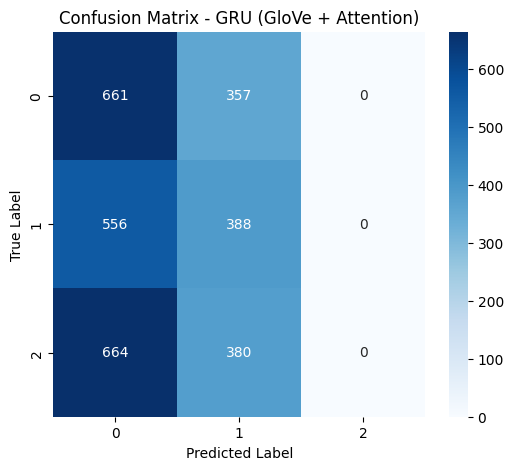

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - GRU (GloVe + Attention)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

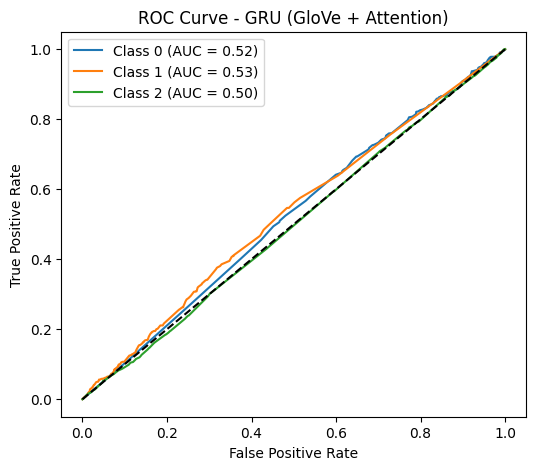

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU (GloVe + Attention)")

plt.legend()
plt.show()

mingru+glove

In [ ]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe embedding layer
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# Mini GRU (32 units)
gru_layer = GRU(32)(embedding_layer)

# Dropout
drop = Dropout(0.3)(gru_layer)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 100, 100)       │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,763 (53.76 KB)

 Trainable params: 12,963 (50.64 KB)

 Non-trainable params: 800 (3.12 KB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.4241 - loss: 1.0828
Epoch 2/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4304 - loss: 1.0674
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4293 - loss: 1.0657
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4341 - loss: 1.0634
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4376 - loss: 1.0607
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4377 - loss: 1.0618
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4371 - loss: 1.0624
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4388 - loss: 1.0609
Epoch 9/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4357 - loss: 1.0615
Epoch 10/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4373 - loss: 1.0617


In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 13763
Parameters (Millions): 0.013763


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results.append({
    "Model": "Mini GRU (GloVe)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [ ]:
results_df = pd.DataFrame(results)
cleaned_mini_gru_glove = results_df[results_df['Model'] == 'Mini GRU (GloVe)'].drop_duplicates(subset=['Model'], keep='last')
print(cleaned_mini_gru_glove)

              Model  Accuracy  Precision    Recall  F1 score  Train Time(sec)  \
2  Mini GRU (GloVe)  0.349967   0.233308  0.353296  0.274223        31.646593   

   Inference Time(sec)  Parameters(M)  
2             0.542806       0.013763  


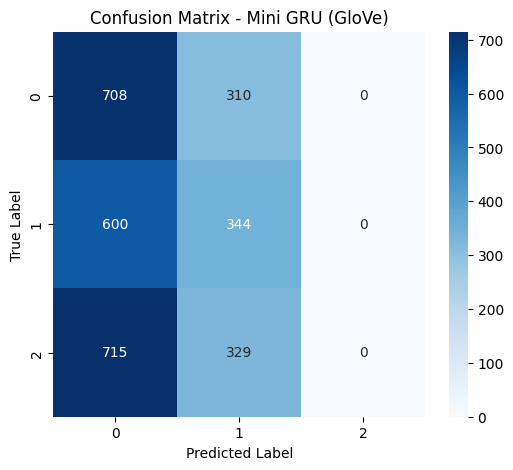

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Mini GRU (GloVe)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

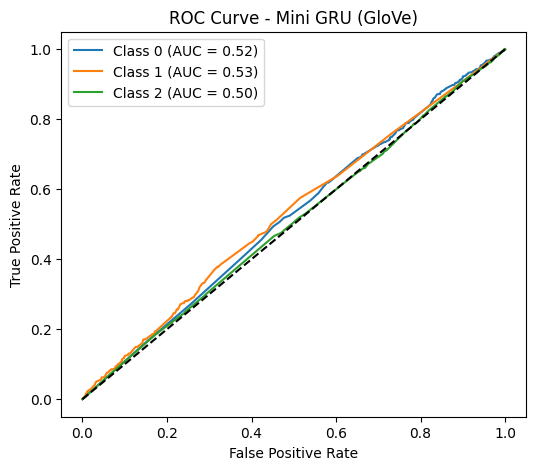

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini GRU (GloVe)")

plt.legend()
plt.show()

mingru +attention

In [ ]:
import time
from tensorflow.keras.layers import Input, GRU, Dense, Embedding
from tensorflow.keras.layers import Attention, GlobalMaxPooling1D, Dropout
from tensorflow.keras.models import Model

start_train = time.time()

# Input layer
input_layer = Input(shape=(max_len,))

# GloVe Embedding
embedding_layer = Embedding(
    vocab_size,
    embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
)(input_layer)

# Mini GRU (32 units)
gru_layer = GRU(32, return_sequences=True)(embedding_layer)

# Attention
attention = Attention()([gru_layer, gru_layer])

# Pooling
pool = GlobalMaxPooling1D()(attention)

# Dropout
drop = Dropout(0.3)(pool)

# Output layer
output = Dense(3, activation='softmax')(drop)

# Model
model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 100, 100)  │        800 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ (None, 100, 32)   │     12,864 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_4         │ (None, 100, 32)   │          0 │ gru_4[0][0],      │
│ (Attention)         │                   │            │ gru_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 32)        │          0 │ attention_4[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32)        │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 3)         │         99 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,763 (53.76 KB)

 Trainable params: 12,963 (50.64 KB)

 Non-trainable params: 800 (3.12 KB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

end_train = time.time()
train_time = end_train - start_train

Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.4116 - loss: 1.0685
Epoch 2/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4292 - loss: 1.0656
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4314 - loss: 1.0647
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4339 - loss: 1.0637
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4337 - loss: 1.0632
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4345 - loss: 1.0620
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4368 - loss: 1.0608
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4378 - loss: 1.0610
Epoch 9/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4389 - loss: 1.0610
Epoch 10/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4370 - loss: 1.0609


In [ ]:
start_inf = time.time()

pred = model.predict(X_test)

end_inf = time.time()

inference_time = end_inf - start_inf

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
import numpy as np

pred_classes = np.argmax(pred, axis=1)

In [ ]:
params = model.count_params()

print("Total Parameters:", params)
print("Parameters (Millions):", params/1e6)

Total Parameters: 13763
Parameters (Millions): 0.013763


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_classes)

precision = precision_score(y_test, pred_classes, average='macro')

recall = recall_score(y_test, pred_classes, average='macro')

f1 = f1_score(y_test, pred_classes, average='macro')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:

results = []
results.append({
    "Model": "Mini GRU (GloVe + Attention)",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 score": f1,
    "Train Time(sec)": train_time,
    "Inference Time(sec)": inference_time,
    "Parameters(M)": params/1e6
})

In [ ]:
results_df = pd.DataFrame(results)
print(results_df[results_df['Model'] == 'Mini GRU (GloVe + Attention)'])

                          Model  Accuracy  Precision    Recall  F1 score  \
0  Mini GRU (GloVe + Attention)  0.350965   0.234252  0.353662  0.272444   

   Train Time(sec)  Inference Time(sec)  Parameters(M)  
0        30.921423             0.566418       0.013763  


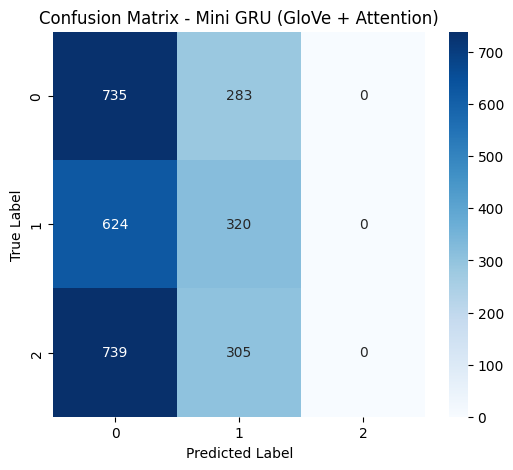

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Mini GRU (GloVe + Attention)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

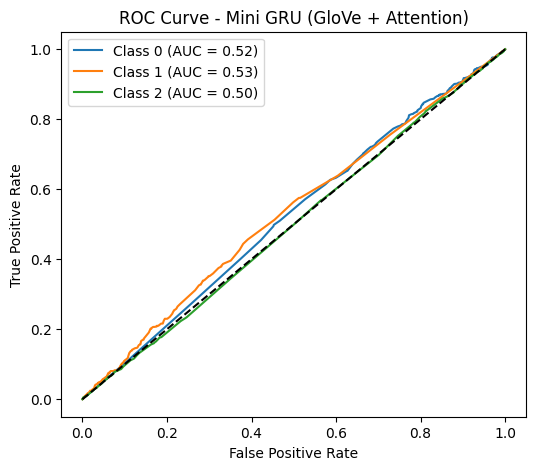

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[0,1,2])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(6,5))

for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Mini GRU (GloVe + Attention)")

plt.legend()
plt.show()